# CARVE Resolution-Mode Tutorial
## Validating Leiden and Louvain Clustering on PBMC 3k

This notebook demonstrates CARVE's **sweep-axis abstraction** -- new features that generalize
the traditional `n_clusters` mode to support:

- **Resolution-based community detection** (Leiden, Louvain)
- **HDBSCAN's `min_cluster_size`** sweep
- **Custom sweep parameters** for novel estimators

**Dataset**: 10x Genomics PBMC 3k (Zheng et al. 2017) -- 2,638 peripheral blood mononuclear cells,
8 annotated immune cell types.

**Prerequisites**: `pip install "carve-validate[graph]"` for Leiden/Louvain support.

For the classic `n_clusters` mode, see the [main Tutorial](Tutorial.ipynb).

## 0. Imports and Configuration

In [1]:
import sys

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

from carve import CARVE, LeidenClustering, LouvainClustering

# --- Configuration ---
SEED = 42
N_RESAMP = 25  # fast for tutorial; use 80-100 for production
MEASURE = "stability"
RULE = "1se"
PALETTE = "tab10"
N_JOBS = 10  # use all cores

plt.rcParams["figure.dpi"] = 120
sc.settings.verbosity = 0

## 1. Load and Prepare Data

We use the preprocessed PBMC 3k dataset from scanpy. The PCA embedding
(`adata.obsm['X_pca']`) serves as our feature matrix -- this is the standard
input for graph-community methods in the single-cell ecosystem.

In [2]:
adata = sc.datasets.pbmc3k_processed()

X = adata.obsm["X_pca"]  # (2638, 50) PCA embedding
umap = adata.obsm["X_umap"]  # precomputed UMAP for scatter plots

# Ground-truth labels (Louvain clustering from the original scanpy tutorial)
cell_types = adata.obs["louvain"].values
cell_type_ids, _ = pd.factorize(cell_types)

print(f"Cells: {X.shape[0]}, PCs: {X.shape[1]}")
print(f"Annotated cell types: {adata.obs['louvain'].nunique()}")
print()
print(adata.obs["louvain"].value_counts())

Cells: 2638, PCs: 50
Annotated cell types: 8

louvain
CD4 T cells          1144
CD14+ Monocytes       480
B cells               342
CD8 T cells           316
NK cells              154
FCGR3A+ Monocytes     150
Dendritic cells        37
Megakaryocytes         15
Name: count, dtype: int64


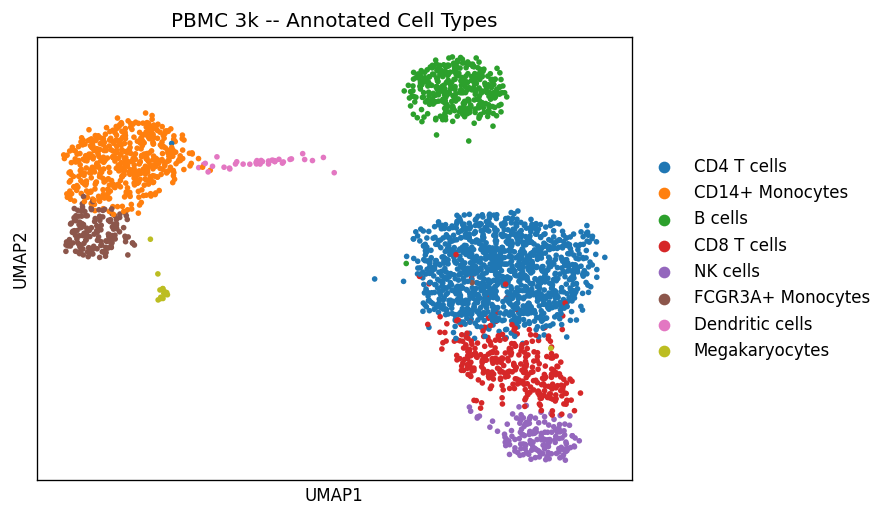

In [3]:
sc.pl.umap(adata, color="louvain", title="PBMC 3k -- Annotated Cell Types")

## 2. Resolution Mode -- Leiden & Louvain Sweep

In **resolution mode**, CARVE sweeps the `resolution` parameter of graph-community
algorithms instead of `n_clusters`. The number of clusters becomes an *observed
outcome* rather than an input.

Pass `resolution=` to the constructor and CARVE automatically uses Leiden and
Louvain as the default estimator grid.

In [4]:
carve_res = CARVE(
    resolution=np.arange(0.05, 1.0, 0.1),  # 10 resolution values
    n_resamples=N_RESAMP,
    n_jobs=N_JOBS,
    random_state=SEED,
    verbose=2,
)
carve_res.fit(X)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 2638
[CARVE] n_features         : 50
[CARVE] sweep parameter    : resolution
[CARVE] resolution         : [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
[CARVE] n_resamples        : 25
[CARVE] subsample_ratio    : 0.618
[CARVE] n_jobs             : 10
[CARVE] total configs      : 20
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/20] est=LeidenClustering resolution=0.05 | ARI_stab=0.993±0.001  ARI_gen=0.952±0.013  
[CARVE] [2/20] est=LeidenClustering resolution=0.15000000000000002 | ARI_stab=0.992±0.001  ARI_gen=0.975±0.001  
[CARVE] [3/20] est=LeidenClustering resolution=0.25000000000000006 | ARI_stab=0.944±0.013  ARI_gen=0.905±0.015  
[CARVE] [4/20] est=LeidenClustering resolution=0.3500000000000001 | ARI_stab=0.941±0.009  

,n_clusters,"array([ 2, 3..., 8, 9, 10])"
,resolution,"array([0.05, ..., 0.85, 0.95])"
,sweep,None
,sweep_values,None
,finer_is_larger,None
,noise_policy,'drop'
,n_resamples,25
,subsample_ratio,0.618
,estimator_param_grids,'light'
,normalization_options,None
,dim_reduction_options,None


### Inspecting the Sweep Axis

After fitting, `sweep_` holds a `SweepSpec` describing what was swept.
Key attributes:

- `param`: the hyperparameter name (`"resolution"`)
- `values`: the swept values
- `fixes_k`: `False` -- resolution does *not* fix the number of clusters
- `finer_is_larger`: `True` -- higher resolution yields more clusters

In [5]:
sweep = carve_res.sweep_

print(f"Sweep param:      {sweep.param}")
print(f"Sweep values:     {sweep.values}")
print(f"fixes_k:          {sweep.fixes_k}")
print(f"finer_is_larger:  {sweep.finer_is_larger}")
print(f"is_k_mode:        {sweep.is_k_mode}")
print(f"Axis label:       {sweep.label}")

Sweep param:      resolution
Sweep values:     [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
fixes_k:          False
finer_is_larger:  True
is_k_mode:        False
Axis label:       Resolution


### Selecting the Best Resolution

- `get_sweep_value()` returns the selected resolution.
- `get_k()` returns the *observed* cluster count at that resolution (rounded mean across resamples).

In [6]:
best_res = carve_res.get_sweep_value(measure=MEASURE, rule=RULE)
best_k = carve_res.get_k(measure=MEASURE, rule=RULE)

print(f"Selected resolution:  {best_res}")
print(f"Observed k:           {best_k}")
print(f"Ground-truth types:   {adata.obs['louvain'].nunique()}")

Selected resolution:  0.15000000000000002
Observed k:           3
Ground-truth types:   8


## 3. Metric and Consensus Plots in Resolution Mode

`plot_metric_over_n_clusters()` adapts to the sweep axis:
- The **x-axis** shows Resolution (not k)
- Separate lines appear for each **method** (Leiden vs Louvain)
- The vertical dashed line marks the selected resolution

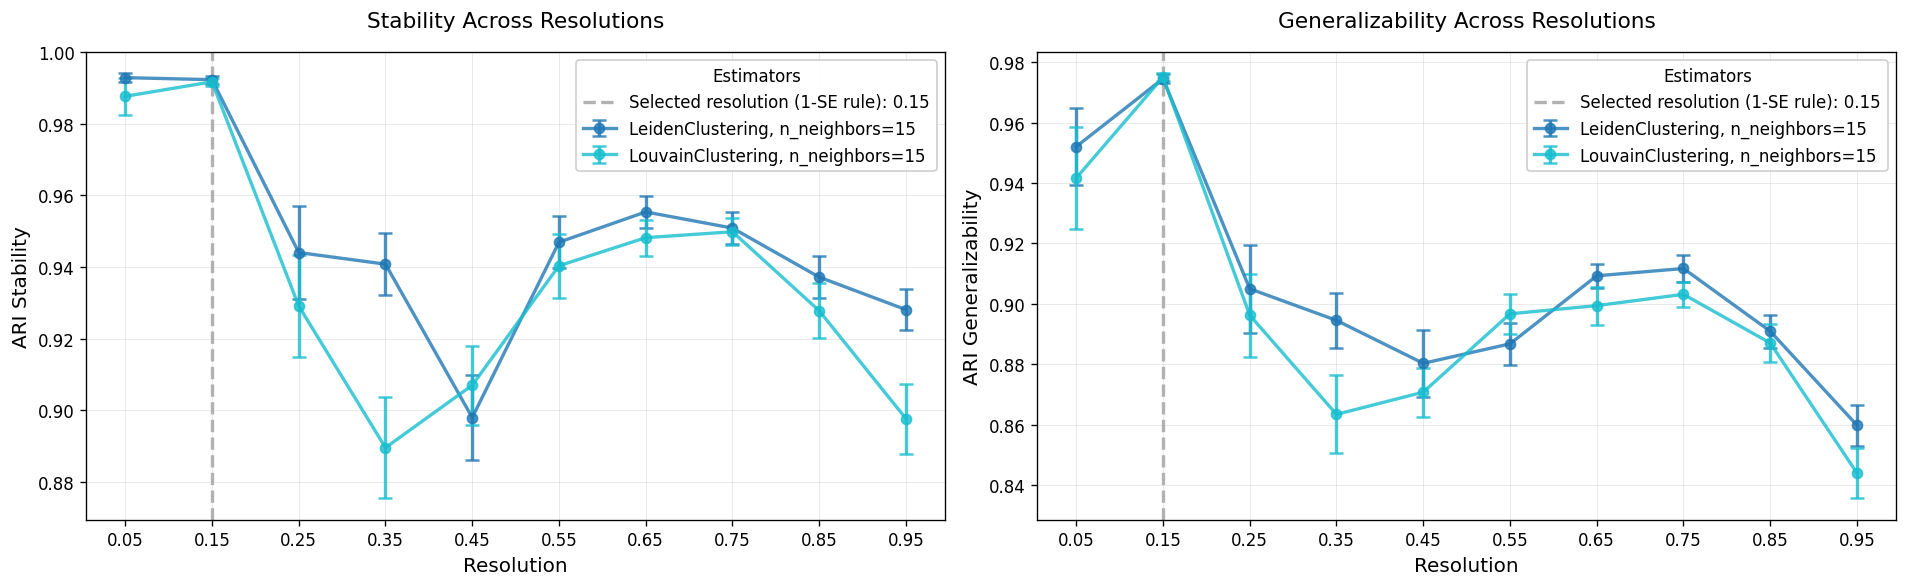

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

carve_res.plot_metric_over_n_clusters(
    measure="stability",
    rule=RULE,
    ax=axes[0],
    title="Stability Across Resolutions",
    palette=PALETTE,
)
carve_res.plot_metric_over_n_clusters(
    measure="generalizability",
    rule=RULE,
    ax=axes[1],
    title="Generalizability Across Resolutions",
    palette=PALETTE,
)
plt.tight_layout()
plt.show()

### Consensus Matrix at Selected Resolution

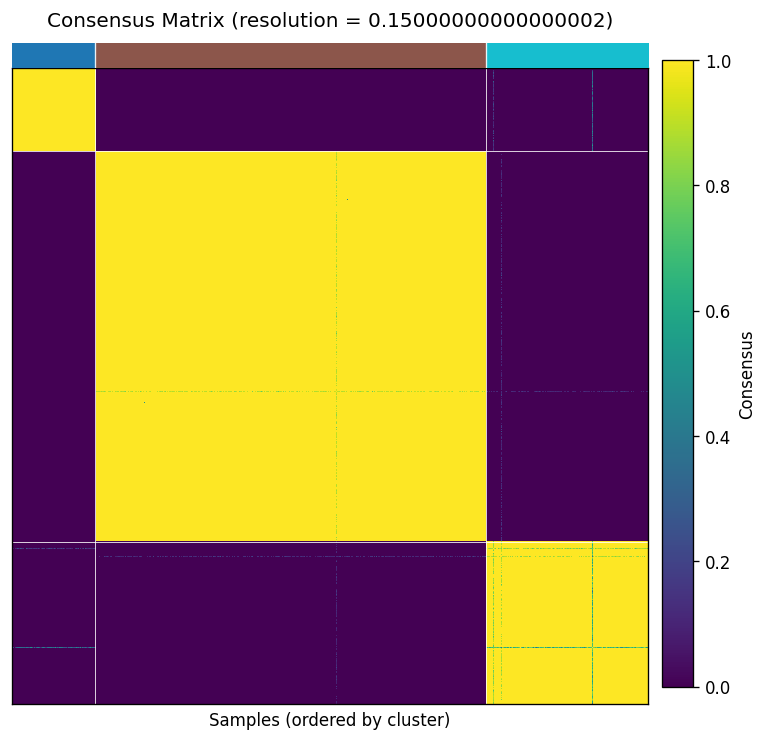

<Axes: title={'center': 'Consensus Matrix (resolution = 0.15000000000000002)'}, xlabel='Samples (ordered by cluster)'>

In [8]:
carve_res.plot_consensus_matrix(
    measure=MEASURE,
    rule=RULE,
    title=f"Consensus Matrix (resolution = {best_res})",
    palette=PALETTE,
    show=True,
)

### Pinning a Different Resolution

Use `sweep_value=` to visualize results at a specific resolution,
regardless of which one the selection rule picked.

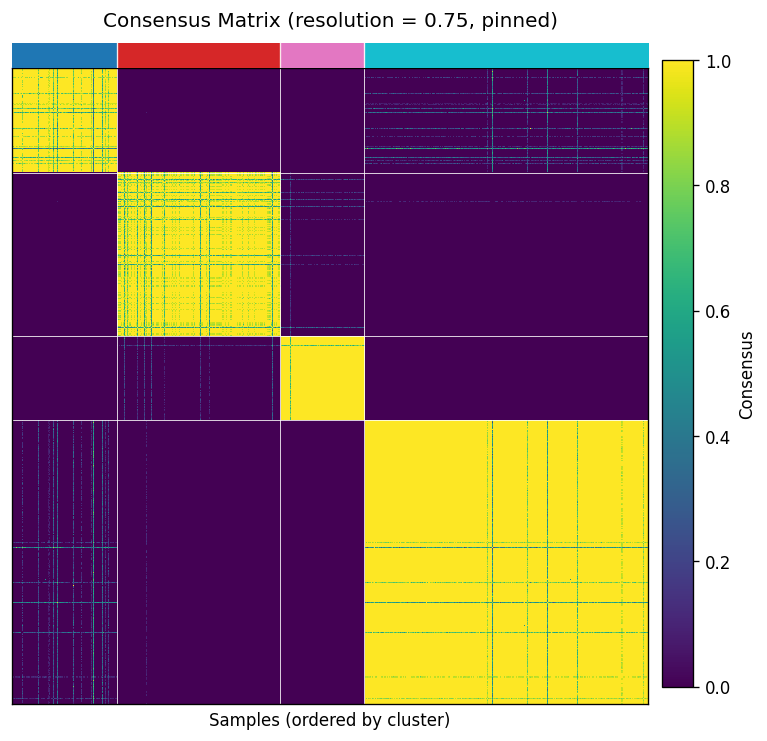

<Axes: title={'center': 'Consensus Matrix (resolution = 0.75, pinned)'}, xlabel='Samples (ordered by cluster)'>

In [10]:
carve_res.plot_consensus_matrix(
    measure=MEASURE,
    rule=RULE,
    sweep_value=0.75,
    title="Consensus Matrix (resolution = 0.75, pinned)",
    palette=PALETTE,
    show=True,
)

## 4. Cluster-Level Diagnostics with `sweep_value=`

All five plotting methods accept `sweep_value=` to pin the analysis to a
specific resolution. We use the PBMC dataset's precomputed UMAP embedding
for the scatter plots.

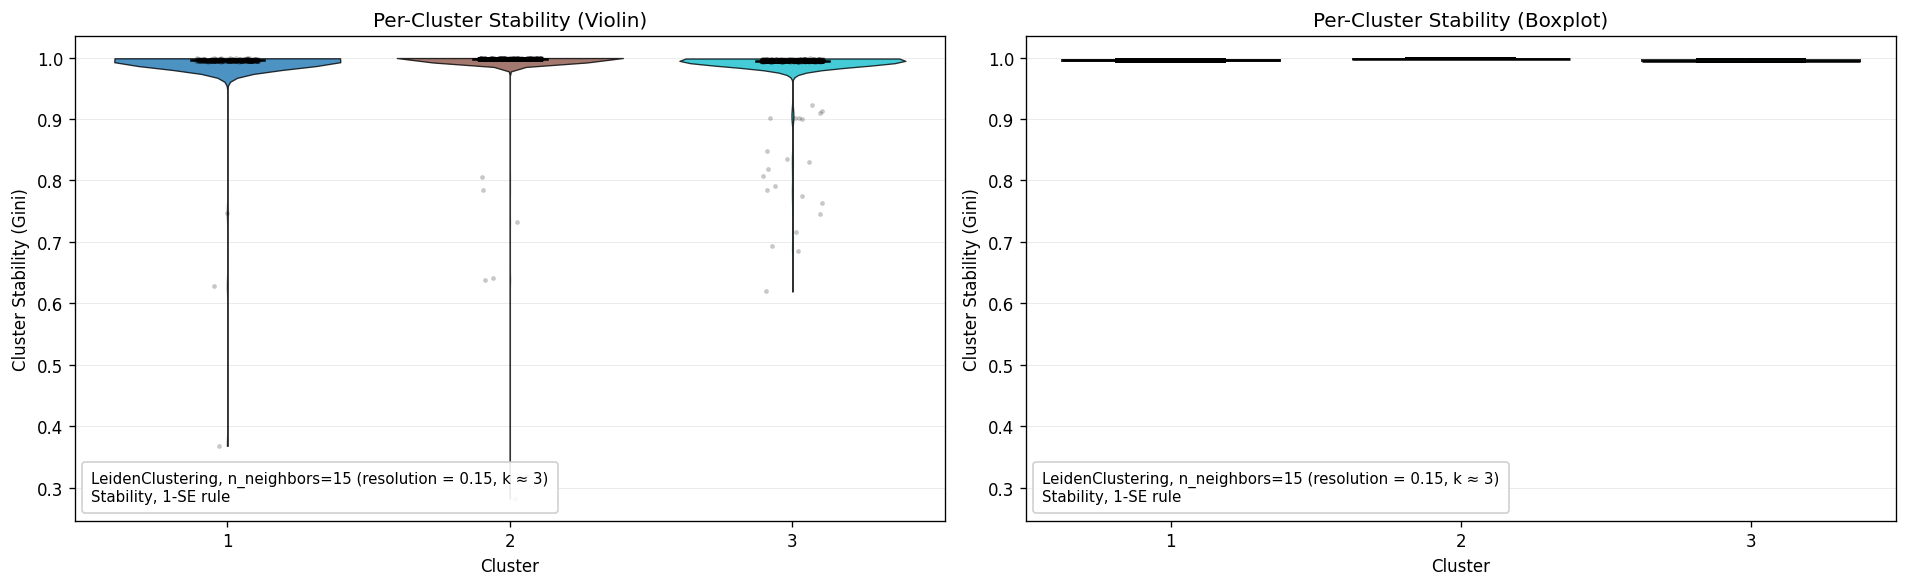

In [11]:
# Violin and boxplot at selected resolution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

carve_res.plot_cluster_violin(
    source="gini",
    measure=MEASURE,
    rule=RULE,
    ax=axes[0],
    title="Per-Cluster Stability (Violin)",
    palette=PALETTE,
)
carve_res.plot_cluster_boxplot(
    source="gini",
    measure=MEASURE,
    rule=RULE,
    ax=axes[1],
    title="Per-Cluster Stability (Boxplot)",
    palette=PALETTE,
)
plt.tight_layout()
plt.show()

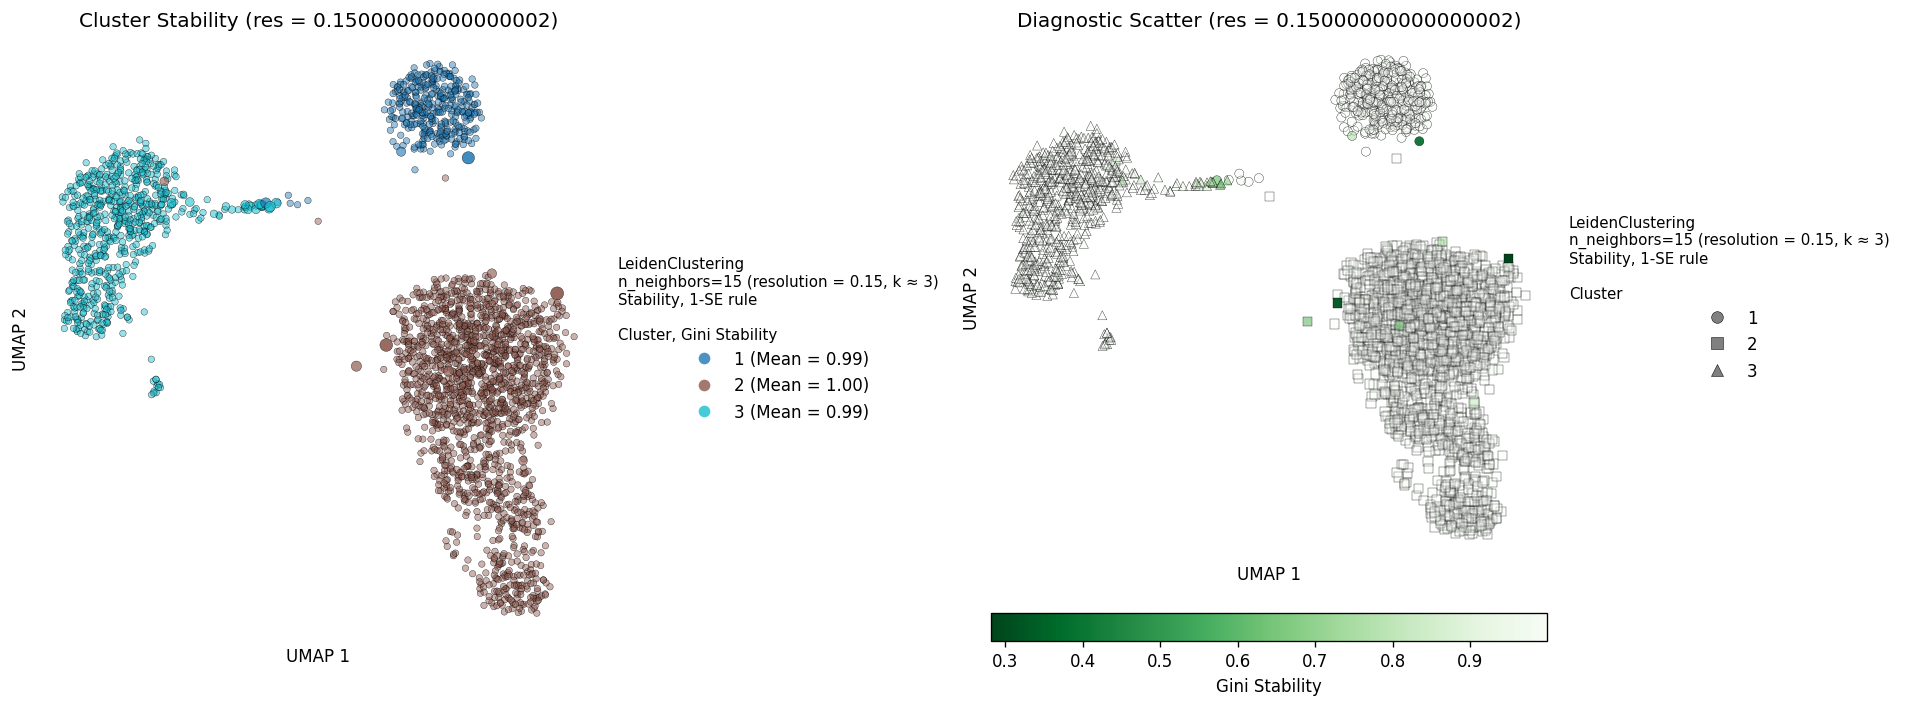

In [12]:
# Scatter plots on UMAP embedding
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

carve_res.plot_cluster_scatter(
    source="gini",
    measure=MEASURE,
    rule=RULE,
    embedding=umap,
    ax=axes[0],
    title=f"Cluster Stability (res = {best_res})",
    xlabel="UMAP 1",
    ylabel="UMAP 2",
    palette=PALETTE,
)
carve_res.plot_diagnostic_scatter(
    source="gini",
    measure=MEASURE,
    rule=RULE,
    embedding=umap,
    ax=axes[1],
    title=f"Diagnostic Scatter (res = {best_res})",
    xlabel="UMAP 1",
    ylabel="UMAP 2",
)
plt.tight_layout()
plt.show()

### Comparing Low vs High Resolution

Pin `sweep_value=` to compare how cluster stability changes across the
resolution spectrum.

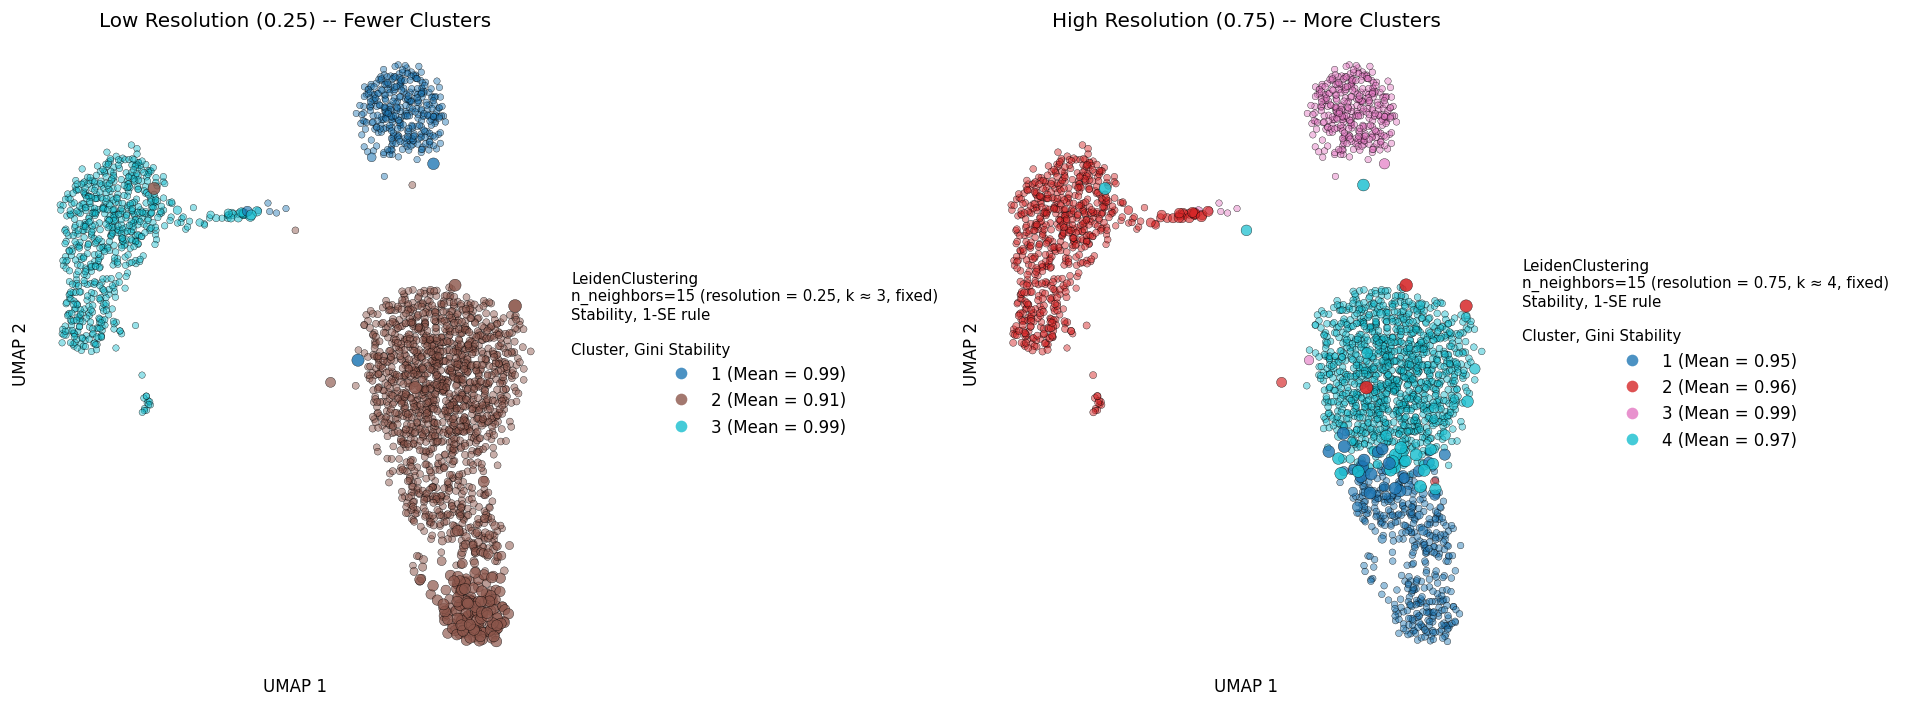

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

carve_res.plot_cluster_scatter(
    source="gini",
    measure=MEASURE,
    rule=RULE,
    sweep_value=0.25,
    embedding=umap,
    ax=axes[0],
    title="Low Resolution (0.25) -- Fewer Clusters",
    xlabel="UMAP 1",
    ylabel="UMAP 2",
    palette=PALETTE,
)
carve_res.plot_cluster_scatter(
    source="gini",
    measure=MEASURE,
    rule=RULE,
    sweep_value=0.75,
    embedding=umap,
    ax=axes[1],
    title="High Resolution (0.75) -- More Clusters",
    xlabel="UMAP 1",
    ylabel="UMAP 2",
    palette=PALETTE,
)
plt.tight_layout()
plt.show()

## 5. Inside `estimator_results_` -- New Sweep Columns

Resolution mode populates several new columns in the results table:

| Column | Description |
|---|---|
| `sweep_param` | Name of the swept parameter (`"resolution"`) |
| `sweep_value` | The resolution value for this row |
| `sweep_rank` | Coarse-to-fine ordering (rank 0 = coarsest) |
| `n_clusters_observed` | Mean cluster count across resamples |
| `n_clusters_observed_se` | Standard error of observed cluster count |
| `noise_fraction` | Fraction of noise points (0 for Leiden/Louvain) |
| `config_id` | Key into per-configuration artifact arrays |
| `method_id` | Groups rows that differ only in sweep value (= one curve) |
| `method_label` | Human-readable label for the method |

In [14]:
cols = [
    "method_label",
    "sweep_param",
    "sweep_value",
    "sweep_rank",
    "n_clusters_observed",
    "n_clusters_observed_se",
    "noise_fraction",
    "config_id",
    "method_id",
    "ari_stability",
    "ari_generalizability",
]
carve_res.estimator_results_[cols]

,method_label,sweep_param,sweep_value,sweep_rank,n_clusters_observed,n_clusters_observed_se,noise_fraction,config_id,method_id,ari_stability,ari_generalizability
0,"LeidenClustering, n_neighbors=15",resolution,0.05,0,3.00,0.000000,0.0,0,m0,0.992904,0.952097
1,"LeidenClustering, n_neighbors=15",resolution,0.15,1,3.00,0.000000,0.0,1,m0,0.992336,0.974603
2,"LeidenClustering, n_neighbors=15",resolution,0.25,2,3.28,0.091652,0.0,2,m0,0.944037,0.904996
3,"LeidenClustering, n_neighbors=15",resolution,0.35,3,4.00,0.000000,0.0,3,m0,0.940791,0.894515
4,"LeidenClustering, n_neighbors=15",resolution,0.45,4,4.00,0.000000,0.0,4,m0,0.897939,0.880297
5,"LeidenClustering, n_neighbors=15",resolution,0.55,5,4.00,0.000000,0.0,5,m0,0.946922,0.886742
6,"LeidenClustering, n_neighbors=15",resolution,0.65,6,4.08,0.055377,0.0,6,m0,0.955385,0.909286
7,"LeidenClustering, n_neighbors=15",resolution,0.75,7,4.20,0.081650,0.0,7,m0,0.950869,0.911710
8,"LeidenClustering, n_neighbors=15",resolution,0.85,8,4.60,0.115470,0.0,8,m0,0.937170,0.890917
9,"LeidenClustering, n_neighbors=15",resolution,0.95,9,4.96,0.107703,0.0,9,m0,0.928068,0.859779


Notice that `n_clusters_observed` varies by resolution -- at low resolutions
Leiden/Louvain find fewer clusters, at high resolutions they find more.
This is the key difference from k-mode, where the cluster count is an *input*.

## 6. Consensus Override with `consensus_k=`

In resolution mode, `get_labels()` cuts the consensus dendrogram at the
observed cluster count by default. You can override this with `consensus_k=`
to explore how the consensus structure looks at a different granularity.

In [15]:
# Default: cut at observed k
labels_default = carve_res.get_labels(measure=MEASURE, rule=RULE)
print(f"Default consensus cut: {np.unique(labels_default).size} clusters")

# Override: force a coarser partition
labels_coarse = carve_res.get_labels(
    measure=MEASURE,
    rule=RULE,
    consensus_k=4,
)
print(f"Forced cut at k=4:    {np.unique(labels_coarse).size} clusters")

Default consensus cut: 3 clusters
Forced cut at k=4:    4 clusters


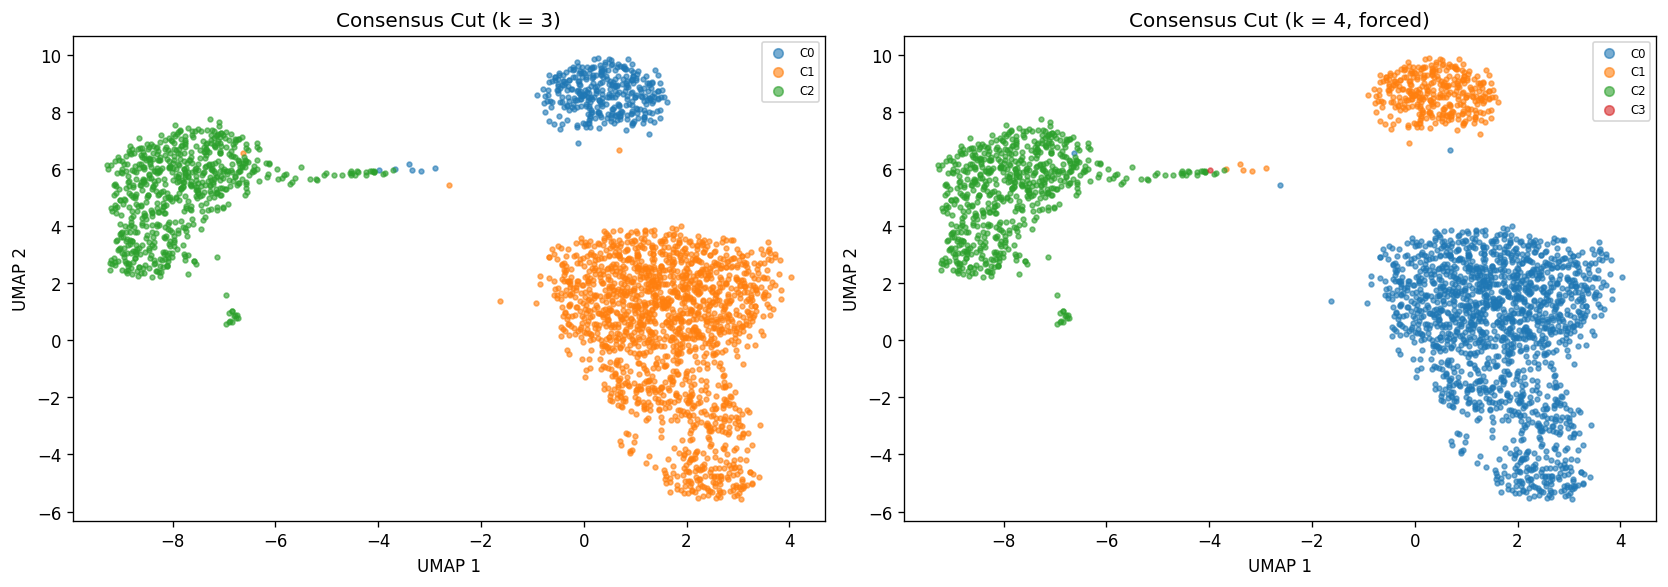

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in [
    (axes[0], labels_default, f"Consensus Cut (k = {np.unique(labels_default).size})"),
    (axes[1], labels_coarse, "Consensus Cut (k = 4, forced)"),
]:
    for c in np.unique(labels):
        mask = labels == c
        ax.scatter(umap[mask, 0], umap[mask, 1], s=8, alpha=0.6, label=f"C{c}")
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(fontsize=7, markerscale=2)

plt.tight_layout()
plt.show()

### Agreement with Ground Truth

In [17]:
ari = adjusted_rand_score(cell_type_ids, labels_default)
print(f"ARI (CARVE labels vs annotated types): {ari:.3f}")

ARI (CARVE labels vs annotated types): 0.583


## 7. HDBSCAN Mode: `min_cluster_size` Sweep

HDBSCAN determines cluster count automatically based on `min_cluster_size`.
CARVE sweeps this parameter and evaluates stability at each setting.

Key difference: HDBSCAN produces **noise points** (label = -1). The
`noise_policy` parameter controls how these are handled:

- `"drop"` (default): noise points are excluded from consensus, ARI, and classifier
- `"as_cluster"`: noise points form an explicit noise cluster
- `"singleton"`: each noise point becomes its own cluster

In [31]:
from sklearn.cluster import HDBSCAN

sweep_values = [3, 5, 10, 15, 20, 30, 50]
estimator_param_grids = [
    (
        HDBSCAN,
        {
            "min_samples": sweep_values,
            "min_cluster_size": [20],
            # "cluster_selection_method": ["eom"],
        },
    ),
]

In [ ]:
carve_hdb = CARVE(
    sweep="min_samples",
    sweep_values=sweep_values,
    estimator_param_grids=estimator_param_grids,
    finer_is_larger=False,
    noise_policy="drop",
    n_resamples=N_RESAMP,
    n_jobs=N_JOBS,
    random_state=SEED,
    verbose=2,
)

carve_hdb.fit(umap)

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 2638
[CARVE] n_features         : 2
[CARVE] sweep parameter    : min_samples
[CARVE] min_samples        : [ 3.  5. 10. 15. 20. 30. 50.]
[CARVE] n_resamples        : 25
[CARVE] subsample_ratio    : 0.618
[CARVE] n_jobs             : 10
[CARVE] total configs      : 7
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...



In [ ]:
# The sweep axis is "min_cluster_size" with finer_is_larger=False
sweep_hdb = carve_hdb.sweep_
print(f"Sweep param:      {sweep_hdb.param}")
print(f"finer_is_larger:  {sweep_hdb.finer_is_larger}")
print(f"Axis label:       {sweep_hdb.label}")

Sweep param:      min_samples
finer_is_larger:  False
Axis label:       Min Samples


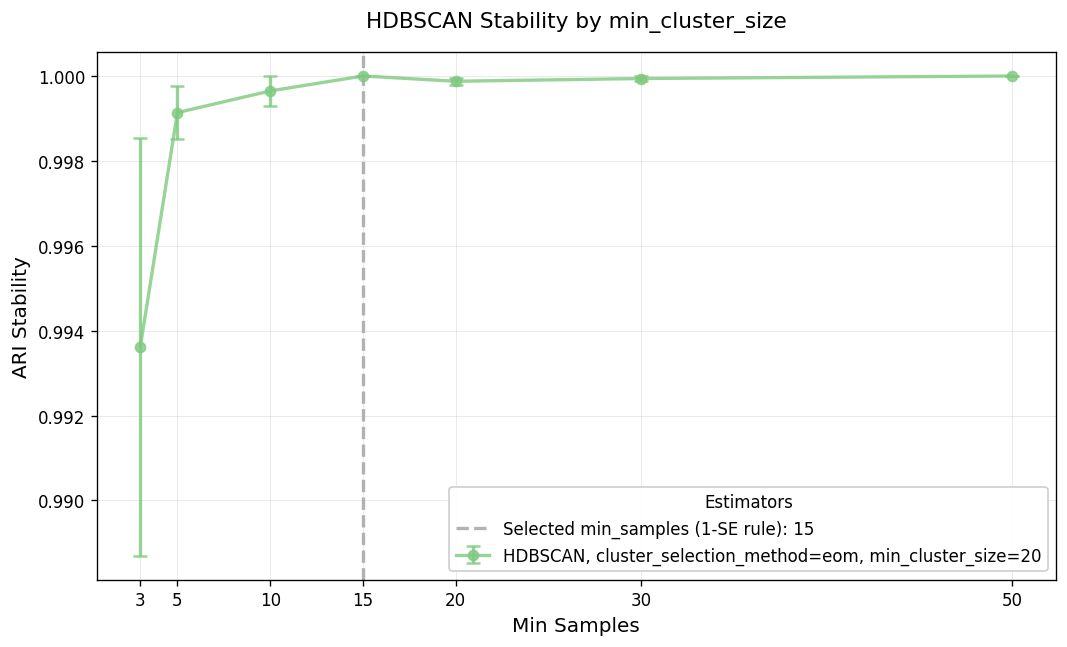

<Axes: title={'center': 'HDBSCAN Stability by min_cluster_size'}, xlabel='Min Samples', ylabel='ARI Stability'>

In [ ]:
carve_hdb.plot_metric_over_n_clusters(
    measure="stability",
    rule="1se",
    title="HDBSCAN Stability by min_cluster_size",
    show=True,
)

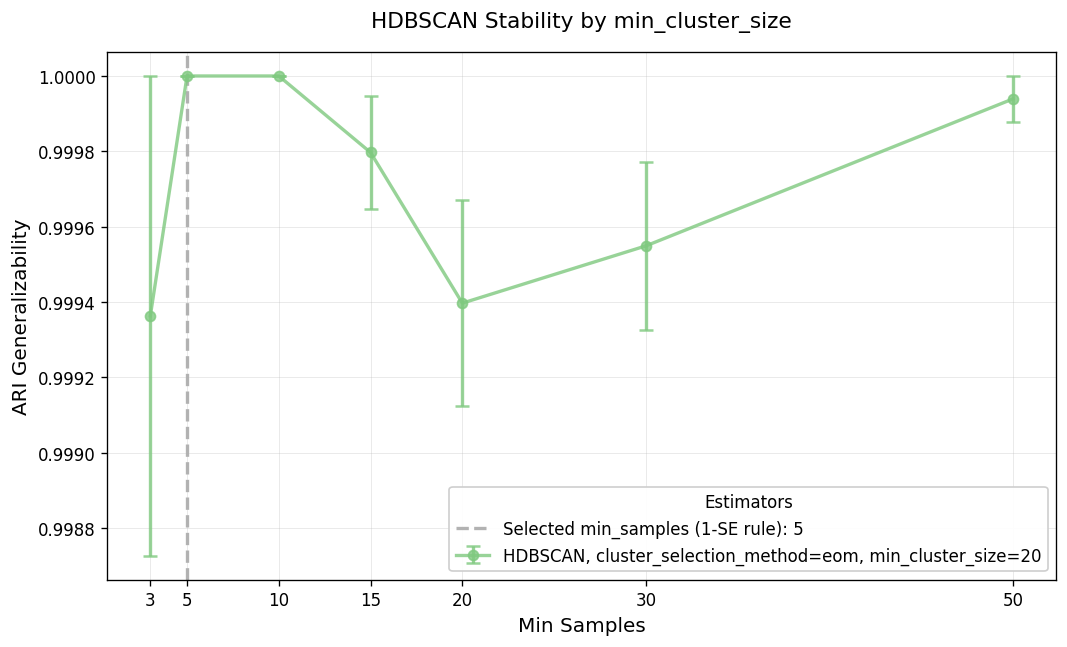

<Axes: title={'center': 'HDBSCAN Stability by min_cluster_size'}, xlabel='Min Samples', ylabel='ARI Generalizability'>

In [ ]:
carve_hdb.plot_metric_over_n_clusters(
    measure="generalizability",
    rule="1se",
    title="HDBSCAN Stability by min_cluster_size",
    show=True,
)

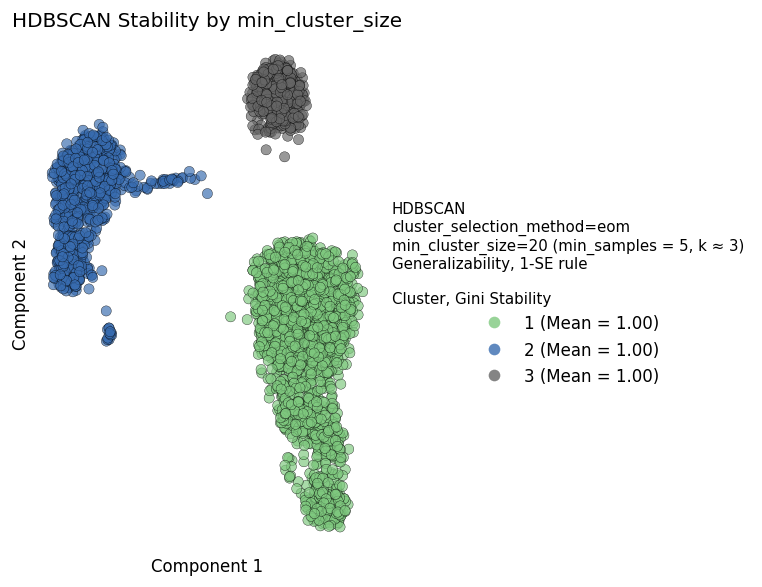

<Axes: title={'center': 'HDBSCAN Stability by min_cluster_size'}, xlabel='Component 1', ylabel='Component 2'>

In [ ]:
carve_hdb.plot_cluster_scatter(
    measure="generalizability",
    rule="1se",
    title="HDBSCAN Stability by min_cluster_size",
    show=True,
)

In [24]:
# Inspect noise fraction across settings
cols = [
    "sweep_value",
    "n_clusters_observed",
    "noise_fraction",
    "ari_stability",
    "method_label",
]
carve_hdb.estimator_results_[cols]

,sweep_value,n_clusters_observed,noise_fraction,ari_stability,method_label
0,3,3.08,0.000417,0.993624,"HDBSCAN, cluster_selection_method=eom, min_clu..."
1,5,3.00,0.000000,0.999138,"HDBSCAN, cluster_selection_method=eom, min_clu..."
2,10,3.00,0.000000,0.999647,"HDBSCAN, cluster_selection_method=eom, min_clu..."
3,15,3.00,0.000000,1.000000,"HDBSCAN, cluster_selection_method=eom, min_clu..."
4,20,3.00,0.000147,0.999876,"HDBSCAN, cluster_selection_method=eom, min_clu..."
5,30,3.00,0.000736,0.999940,"HDBSCAN, cluster_selection_method=eom, min_clu..."
6,50,3.00,0.001301,1.000000,"HDBSCAN, cluster_selection_method=eom, min_clu..."


Notice how `noise_fraction` increases with larger `min_cluster_size` -- more
points are classified as noise when HDBSCAN requires larger minimum clusters.

## 8. Custom Estimator Grids with Auto-Inference

You can pass custom grids with any `resolution`-bearing estimator and CARVE
infers the sweep parameter automatically -- no need to separately pass
`resolution=` or `sweep=`.

### Standalone Estimators

`LeidenClustering` and `LouvainClustering` are full sklearn-compatible
estimators, usable independently of CARVE.

In [25]:
leiden = LeidenClustering(resolution=1.0, n_neighbors=15)
leiden.fit(X)
print(
    f"Leiden (res=1.0): {leiden.n_clusters_} clusters, quality = {leiden.quality_:.3f}"
)

louvain = LouvainClustering(resolution=1.0, n_neighbors=15)
louvain.fit(X)
print(
    f"Louvain (res=1.0): {louvain.n_clusters_} clusters, modularity = {louvain.modularity_:.3f}"
)

Leiden (res=1.0): 6 clusters, quality = 44301.532
Louvain (res=1.0): 6 clusters, modularity = 0.633


### Custom Grid: Comparing Neighborhood Sizes

Here we build a custom grid that varies `n_neighbors` to see how
graph construction affects clustering stability.

In [26]:
custom_grids = [
    (
        LeidenClustering,
        {
            "resolution": [0.4, 0.6, 0.8, 1.0, 1.2, 1.5],
            "n_neighbors": [10],
        },
    ),
    (
        LeidenClustering,
        {
            "resolution": [0.4, 0.6, 0.8, 1.0, 1.2, 1.5],
            "n_neighbors": [30],
        },
    ),
]

carve_custom = CARVE(
    estimator_param_grids=custom_grids,
    n_resamples=N_RESAMP,
    n_jobs=N_JOBS,
    random_state=SEED,
    verbose=2,
)

carve_custom.fit(X)

# sweep="resolution" was inferred from the grids
print(f"\nInferred sweep: {carve_custom.sweep_.param}")

[CARVE] ============================================================
[CARVE] Validation Settings:
[CARVE] n_samples          : 2638
[CARVE] n_features         : 50
[CARVE] sweep parameter    : resolution
[CARVE] resolution         : [0.4 0.6 0.8 1.  1.2 1.5]
[CARVE] n_resamples        : 25
[CARVE] subsample_ratio    : 0.618
[CARVE] n_jobs             : 10
[CARVE] total configs      : 12
[CARVE] randomize_preproc  : False
[CARVE] random_state       : 42
[CARVE] ============================================================

[CARVE] Starting validation ...

[CARVE] [1/12] est=LeidenClustering resolution=0.4 | ARI_stab=0.895±0.012  ARI_gen=0.864±0.010  
[CARVE] [2/12] est=LeidenClustering resolution=0.6 | ARI_stab=0.941±0.006  ARI_gen=0.906±0.004  
[CARVE] [3/12] est=LeidenClustering resolution=0.8 | ARI_stab=0.914±0.006  ARI_gen=0.882±0.006  
[CARVE] [4/12] est=LeidenClustering resolution=1.0 | ARI_stab=0.907±0.009  ARI_gen=0.854±0.011  
[CARVE] [5/12] est=LeidenClustering resolution=1.2 |

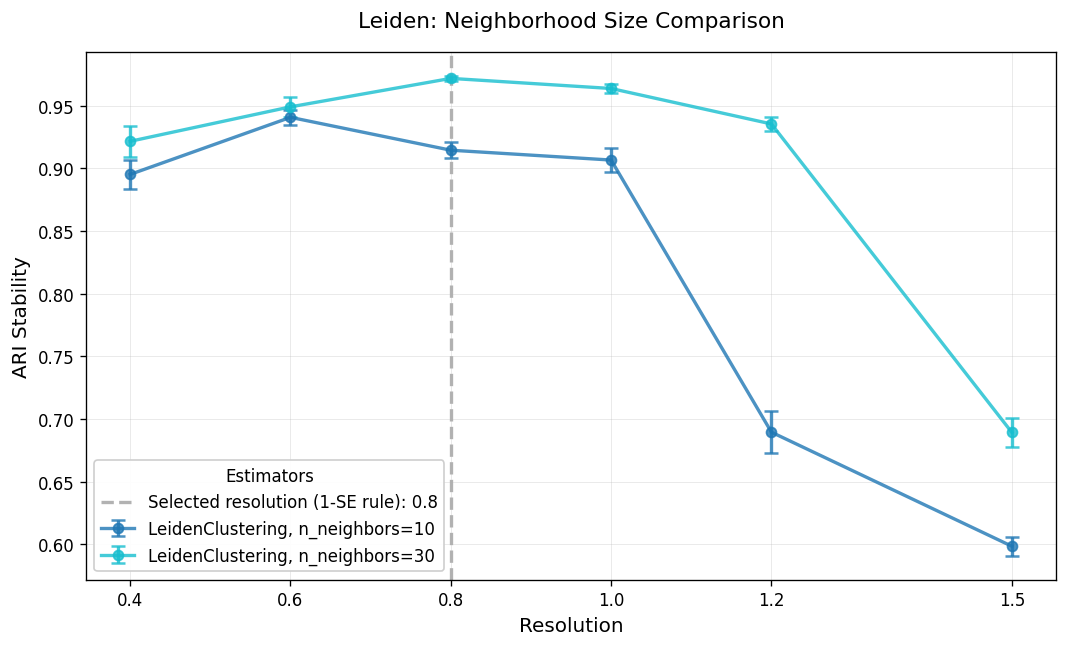

<Axes: title={'center': 'Leiden: Neighborhood Size Comparison'}, xlabel='Resolution', ylabel='ARI Stability'>

In [27]:
# Each n_neighbors value produces a separate line (method)
carve_custom.plot_metric_over_n_clusters(
    measure="stability",
    rule="1se",
    title="Leiden: Neighborhood Size Comparison",
    palette=PALETTE,
    show=True,
)

In [28]:
# The method_label column shows how the two grids are distinguished
carve_custom.estimator_results_[
    ["method_id", "method_label", "sweep_value", "n_clusters_observed", "ari_stability"]
]

,method_id,method_label,sweep_value,n_clusters_observed,ari_stability
0,m0,"LeidenClustering, n_neighbors=10",0.4,4.08,0.895154
1,m0,"LeidenClustering, n_neighbors=10",0.6,4.64,0.940687
2,m0,"LeidenClustering, n_neighbors=10",0.8,5.16,0.914456
3,m0,"LeidenClustering, n_neighbors=10",1.0,6.08,0.906600
4,m0,"LeidenClustering, n_neighbors=10",1.2,7.40,0.689423
5,m0,"LeidenClustering, n_neighbors=10",1.5,9.84,0.598392
6,m1,"LeidenClustering, n_neighbors=30",0.4,3.96,0.921557
7,m1,"LeidenClustering, n_neighbors=30",0.6,4.00,0.949060
8,m1,"LeidenClustering, n_neighbors=30",0.8,4.00,0.971771
9,m1,"LeidenClustering, n_neighbors=30",1.0,4.04,0.963710


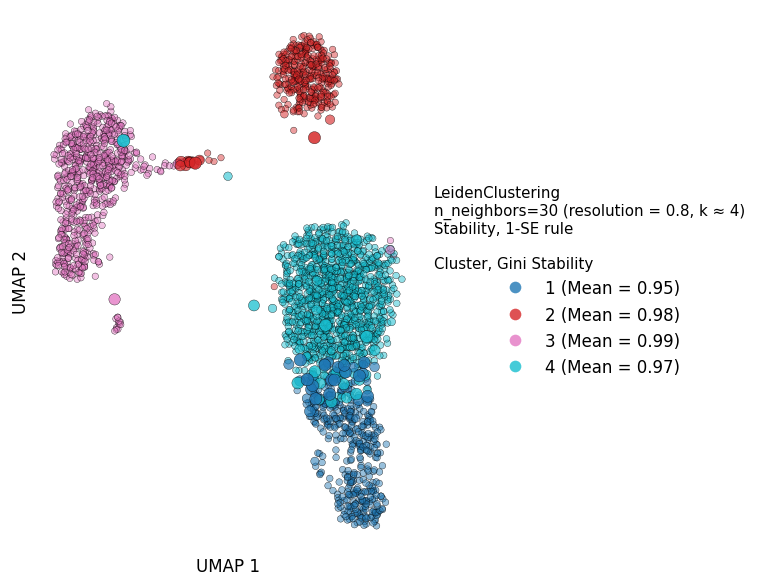

<Axes: xlabel='UMAP 1', ylabel='UMAP 2'>

In [29]:
carve_custom.plot_cluster_scatter(
    measure="stability",
    rule="1se",
    palette=PALETTE,
    show=True,
    embedding=umap,
    xlabel="UMAP 1",
    ylabel="UMAP 2",
)

## 9. Saving and Loading

Fitted CARVE instances with resolution metadata persist across save/load.

In [30]:
# Uncomment to save
# carve_res.save("pbmc3k_resolution.carve", include_data=True)

# Uncomment to load
# carve_loaded = CARVE.load("pbmc3k_resolution.carve")
# print(f"Loaded sweep: {carve_loaded.sweep_.param}")
# print(f"Selected resolution: {carve_loaded.get_sweep_value()}")

## Summary

This tutorial demonstrated CARVE's new sweep-axis features:

| Feature | API |
|---|---|
| Resolution mode | `CARVE(resolution=...)` |
| HDBSCAN mode | `CARVE(sweep="min_cluster_size", sweep_values=...)` |
| Custom grids | `CARVE(estimator_param_grids=[(LeidenClustering, {...})])` |
| Selected sweep value | `get_sweep_value()` |
| Observed k | `get_k()` returns observed cluster count |
| Pinned plots | `plot_*(sweep_value=0.8)` |
| Consensus override | `get_labels(consensus_k=4)` |
| Noise handling | `noise_policy="drop"` / `"as_cluster"` / `"singleton"` |
| Default grids | Auto-detected: Leiden+Louvain for resolution, HDBSCAN for min_cluster_size |
| Sweep metadata | `estimator_results_` columns: `sweep_param`, `sweep_value`, `method_id`, ... |
| Standalone estimators | `LeidenClustering`, `LouvainClustering` as sklearn-compatible classes |

For the classic `n_clusters` mode, see the [main Tutorial](Tutorial.ipynb).